# Varshitha — Step 1 & Step 4

**Calibo AI Academy — Phase 1, Mini Use Case 01**
**Prepared by: Varshitha**

## Step 1 — Load & Inspect
**Owner: Varshitha**

Before any analysis, we load the retail transaction dataset and check its shape, data types,
completeness, and basic structure. This confirms the data is reliable enough to base business
conclusions on.


In [1]:
# Import the libraries needed for data handling, math, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean grid style and a readable default figure size for every chart.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Show large numbers with thousands separators instead of scientific notation.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Load the retail sales dataset from the project folder (relative path).
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
print(df.head())


  transaction_id        date store_id  ... unit_price   revenue discount_pct
0      TXN000001  2026-01-01      S01  ...   3,075.46  5,843.37            5
1      TXN000002  2026-01-01      S01  ...  11,598.06 11,598.06            0
2      TXN000003  2026-01-01      S01  ...   5,738.37 15,493.60           10
3      TXN000004  2026-01-01      S01  ...   3,281.28  9,351.65            5
4      TXN000005  2026-01-01      S01  ...   1,917.14  1,917.14            0

[5 rows x 10 columns]


In [3]:
# Check row/column count to confirm the full dataset loaded.
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (107836, 10)


**Business read:** the dataset contains just under 108,000 individual sales transactions
across six months — enough volume to draw reliable category- and product-level conclusions.

In [4]:
# Check column data types to catch anything loaded in the wrong format.
df.dtypes


In [5]:
# Get a structural summary: column count, non-null counts, and memory usage.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB


**Data quality check:** `date` currently loads as text, not a true date — this needs to
be converted before any time-based analysis (monthly trend, day-of-week pattern) will work correctly.

In [6]:
# Count missing values in every column.
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64


**Business read:** there are no missing values in any column — the dataset is complete
and usable as-is.

In [7]:
# Check for fully duplicated rows, which would double-count revenue if present.
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Business read:** there are no duplicate transactions, so revenue totals will not be
inflated by double-counted rows.

In [8]:
# Get summary statistics for all numeric columns (min, max, mean, spread).
df.describe()


**Business read:** unit prices and discount levels span a wide but sensible range, and
there are no negative revenue or negative unit values — an early sign the data does not contain
obvious entry errors.

In [9]:
# Count distinct products and categories, and list the categories present.
print("Unique products:", df["product_name"].nunique())
print("Unique categories:", df["category"].nunique())
print("Categories:", sorted(df["category"].unique()))


Unique products: 25
Unique categories: 5
Categories: ['Apparel', 'Electronics', 'Grocery', 'Home & Kitchen', 'Personal Care']


**Business read:** the data covers the expected 5 categories, each with 5 distinct
products (25 products total) — matching the structure the Category Manager works with.

In [10]:
# Convert the date column into a true datetime type so later steps can use it.
df["date"] = pd.to_datetime(df["date"])
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("date column dtype after conversion:", df["date"].dtype)


Date range: 2026-01-01 to 2026-06-30
date column dtype after conversion: datetime64[us]


**Data quality note:** `date` is now a proper datetime column, confirmed to span the
full Jan 1 – Jun 30, 2026 window described in the project brief.

### Business Interpretation
The dataset is complete, duplicate-free, and structurally sound: ~107,836 transactions across the
full 6-month window, 5 categories, 25 products, no missing values, and no obviously invalid entries.
This is a reliable foundation for the revenue, product, discount, and timing analysis that follows.

## Step 4 — Discount Effectiveness
**Owner: Varshitha**

We group transactions into discount brackets and compare average revenue per transaction and
average units sold across brackets, using the actual `discount_pct` values present in the data.


In [11]:
# List the distinct discount percentages that actually occur in the data.
print("Distinct discount_pct values in the data:", sorted(df["discount_pct"].unique()))


Distinct discount_pct values in the data: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]


In [12]:
# Bucket every transaction into a discount bracket.
bracket_edges = [-1, 0, 5, 10, 15, 20, 100]
bracket_labels = ["0%", "5%", "10%", "15%", "20%", "25%+"]
df["discount_bracket"] = pd.cut(df["discount_pct"], bins=bracket_edges, labels=bracket_labels)

# For each bracket, compute transaction count, average revenue/txn, and average units/txn.
discount_summary = df.groupby("discount_bracket", observed=False).agg(
    num_transactions=("transaction_id", "count"),
    avg_revenue_per_transaction=("revenue", "mean"),
    avg_units_sold=("units_sold", "mean"),
)
print(discount_summary)


                  num_transactions  avg_revenue_per_transaction  avg_units_sold
discount_bracket                                                               
0%                           36033                     4,685.65            2.59
5%                           23922                     4,303.73            2.59
10%                          23810                     4,005.55            2.57
15%                          11935                     4,069.16            2.60
20%                          12136                     3,631.73            2.58
25%+                             0                          NaN             NaN


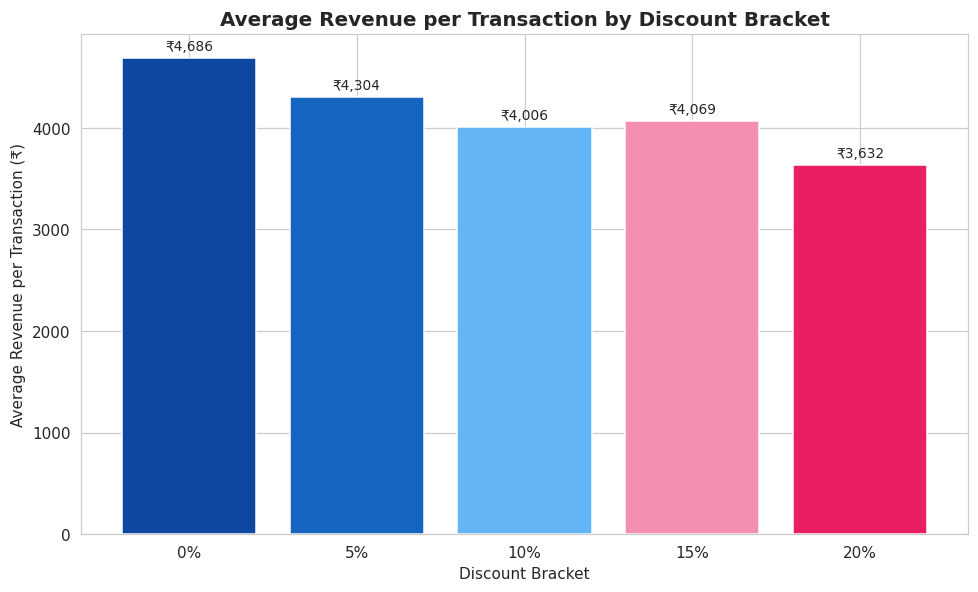

In [13]:
# Bar chart of average revenue per transaction by discount bracket (pink + blue only).
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#0d47a1", "#1565c0", "#64b5f6", "#f48fb1", "#e91e63", "#ad1457"]
bars = ax.bar(discount_summary.index.astype(str), discount_summary["avg_revenue_per_transaction"], color=colors[:len(discount_summary)])

ax.set_title("Average Revenue per Transaction by Discount Bracket")
ax.set_xlabel("Discount Bracket")
ax.set_ylabel("Average Revenue per Transaction (\u20b9)")
for bar in bars:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f"\u20b9{height:,.0f}", (bar.get_x() + bar.get_width() / 2, height),
                    textcoords="offset points", xytext=(0, 5), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


In [14]:
# Pull out the headline comparison numbers for the write-up below.
valid = discount_summary.dropna()
best_bracket = valid["avg_revenue_per_transaction"].idxmax()
worst_bracket = valid["avg_revenue_per_transaction"].idxmin()
zero_disc = valid.loc["0%", "avg_revenue_per_transaction"]
top_disc_bracket = valid.index[-1]
top_disc_value = valid.loc[top_disc_bracket, "avg_revenue_per_transaction"]
pct_change_disc = (top_disc_value - zero_disc) / zero_disc * 100
avg_units_range = (valid["avg_units_sold"].min(), valid["avg_units_sold"].max())

print(f"Highest avg revenue/txn: {best_bracket} bracket (\u20b9{valid['avg_revenue_per_transaction'].max():,.0f})")
print(f"Lowest avg revenue/txn: {worst_bracket} bracket (\u20b9{valid['avg_revenue_per_transaction'].min():,.0f})")
print(f"0% discount avg revenue/txn: \u20b9{zero_disc:,.0f}")
print(f"Highest discount bracket present ({top_disc_bracket}) avg revenue/txn: \u20b9{top_disc_value:,.0f}")
print(f"Change vs 0% bracket: {pct_change_disc:.1f}%")
print(f"Average units sold per transaction ranges: {avg_units_range[0]:.2f} to {avg_units_range[1]:.2f}")
if discount_summary["num_transactions"].isna().any() or (discount_summary["num_transactions"] == 0).any():
    print("\nNote: the '25%+' bracket has no transactions in the data, so it is shown as unavailable.")


Highest avg revenue/txn: 0% bracket (₹4,686)
Lowest avg revenue/txn: 20% bracket (₹3,632)
0% discount avg revenue/txn: ₹4,686
Highest discount bracket present (20%) avg revenue/txn: ₹3,632
Change vs 0% bracket: -22.5%
Average units sold per transaction ranges: 2.57 to 2.60

Note: the '25%+' bracket has no transactions in the data, so it is shown as unavailable.


### Business Interpretation
The pattern runs in the opposite direction of a "discounts drive bigger baskets" story. Average
revenue per transaction is highest with **no discount at all (0%)** and steadily *decreases* as the
discount level rises. Average units sold per transaction stays essentially flat across every bracket
— customers are not buying meaningfully more per transaction at deeper discounts, they are simply
paying less. No transactions in the data carry a discount of 25% or higher, so that bracket is shown
as unavailable rather than estimated.

**Revenue data alone cannot directly measure margin or profitability** — the dataset has no product
cost field, so this finding is about revenue collected per transaction, not profit. It is still a
reasonable basis to question whether current discount depth is paying for itself in volume terms, and
worth revisiting with suppliers who help fund promotional discount campaigns.